In [ ]:
import os
os.getcwd()
os.getcwd()
# sc
import pegasus as pg
import matplotlib.pyplot as plt

# plotting
import seaborn as sns

# data
import numpy as np
import pandas as pd

# sys
import gc
from pathlib import Path

# pge
import sys
import os
import scanpy as sc
import sys
import pytest

In [3]:
import pge
pge.info()


scanpy==1.9.3 anndata==0.9.1 umap==0.5.3 numpy==1.23.5 scipy==1.11.4 pandas==2.1.3 scikit-learn==1.3.0 statsmodels==0.14.0 python-igraph==0.9.10 pynndescent==0.5.10
pegasus extentions - collection of custom functions for pegasus
pegasus v1.8.0
scanpy v1.9.3
anndata v0.9.1
numpy v1.23.5
pandas v2.1.3


In [4]:
# Load the Scanpy object
input_Fresh_h5ad = '...'
input_Biopsies = '...'
input_Biopsies2 = '...'

output_png1 = "Pearson_Fresh_Biopsies.png"

In [ ]:
# ============ 230424_FreshMG_freeze3 ==============
Fresh = pge.pb_agg_by_cluster(h5ad_file=input_Fresh_h5ad,
                           cluster_label='subtype',
                           robust_var_label='robust_protein_coding',
                           log1p=True)
Fresh.to_csv('result/2024_FreshMG_pbagg.csv')
# ------------------------------------------
# ------------------------------------------

In [6]:
adata = sc.read_h5ad(input_Biopsies)

In [7]:
adata.layers["raw.X"] = adata.layers["counts"].copy()

In [8]:
adata.write_h5ad(input_Biopsies2)

In [ ]:
sc.pl.umap(adata, color='predictions_subtype')

In [ ]:
# ========= Biopsies =========
Biopsies = pge.pb_agg_by_cluster(h5ad_file=input_Biopsies,
                           cluster_label='predictions_subtype',
                           robust_var_label= None,
                           log1p=True)
Biopsies.to_csv('2024_Biopsies_pbagg.csv')
# ------------------------------------------
# ------------------------------------------

In [11]:



# =============== SCALE COUNTS =============
Biopsies_scaled = (Biopsies - np.mean(Biopsies, axis=0)) / np.std(Biopsies, axis=0)
Fresh_scaled = (Fresh - np.mean(Fresh, axis=0)) / np.std(Fresh, axis=0)
# ------------------------------------------


In [12]:
# Remove the common prefix and underscore from the index
Biopsies_scaled.index = Biopsies_scaled.index.str.split('_').str[1]
Fresh_scaled.index = Fresh_scaled.index.str.split('_').str[1]


In [13]:
# Sort the index alphabetically
Biopsies_scaled_sorted = Biopsies_scaled.sort_index(axis=0)
Fresh_scaled_sorted = Fresh_scaled.sort_index(axis=0)


In [14]:
custom_order = ['AIF1','CCL3','HIF1A',
'HIST',
'HSPA1A','IFI44L','TMEM163',
'FRMD4A','PICALM',
'CD163','GPNMB',
'MKI67','ERN1']
# Reindex the DataFrame with the custom order
Biopsies_scaled_sorted_reordered = Biopsies_scaled_sorted.reindex(custom_order)
Fresh_scaled_sorted_reordered = Fresh_scaled_sorted.reindex(custom_order)


In [28]:
# Change the name of the first row (index label)
new_index_name = 'AIF1_Fresh'
Fresh_scaled_sorted_reordered = Fresh_scaled_sorted_reordered.rename(index={Fresh_scaled_sorted_reordered.index[0]: new_index_name})

In [30]:
corr_mat_pge = pge.pearson_corr(Fresh_scaled_sorted_reordered,
                                    Biopsies_scaled_sorted_reordered)

Shared gene names: 1472


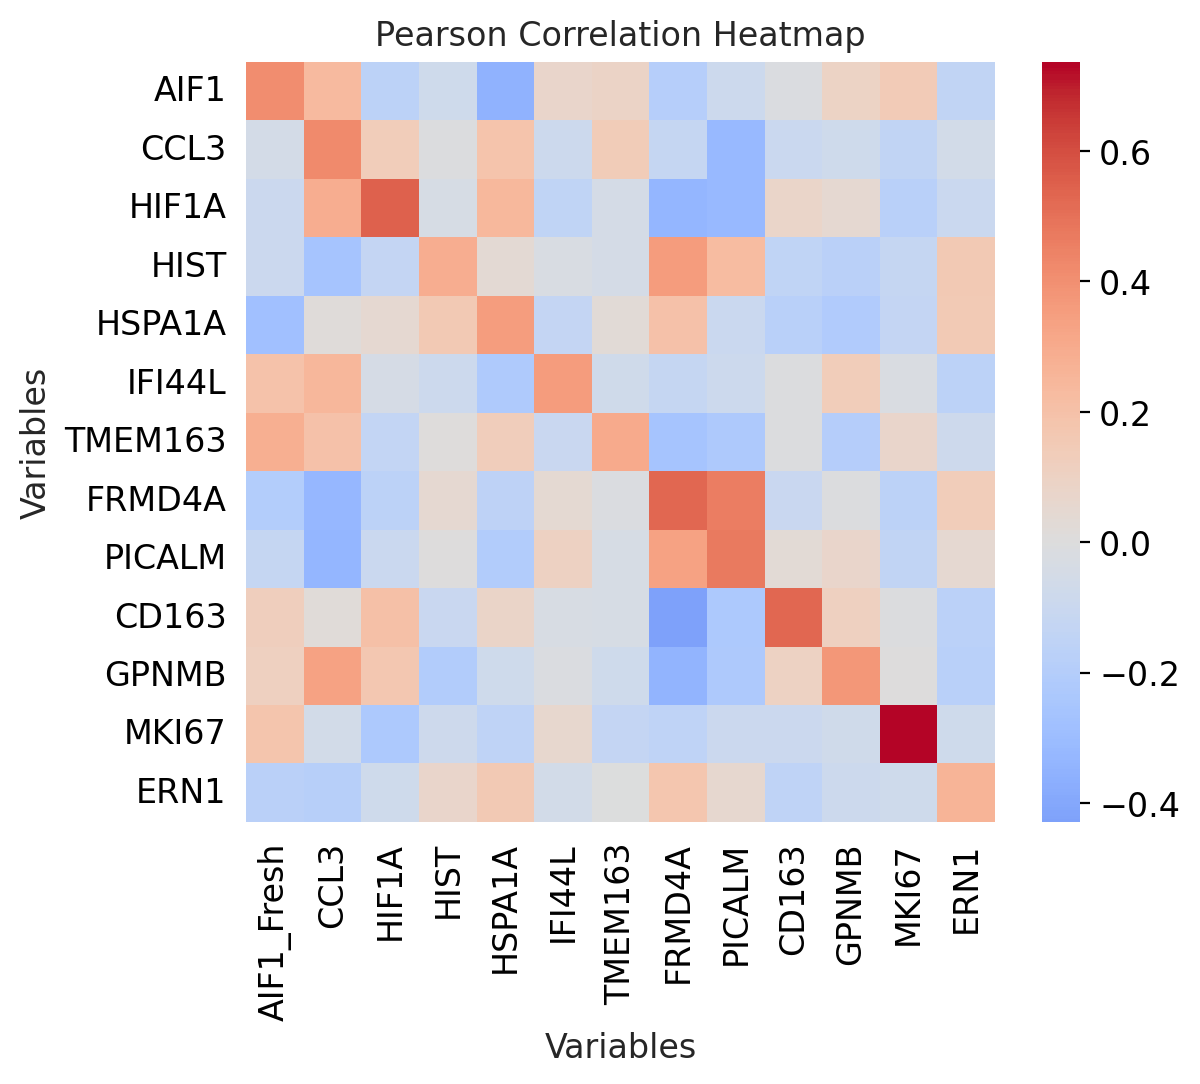

In [32]:
# Plot the heatmap with colors from blue to red
plt.figure(figsize=(6, 5))
sns.heatmap(corr_mat_pge, cmap='coolwarm', center=0, annot=False, fmt=".2f")
plt.title('Pearson Correlation Heatmap')
plt.xlabel('Variables')
plt.ylabel('Variables')

plt.savefig('SupFigures/SFigure2A.pdf', format='pdf', bbox_inches='tight') 
plt.show()


Shared gene names: 1472


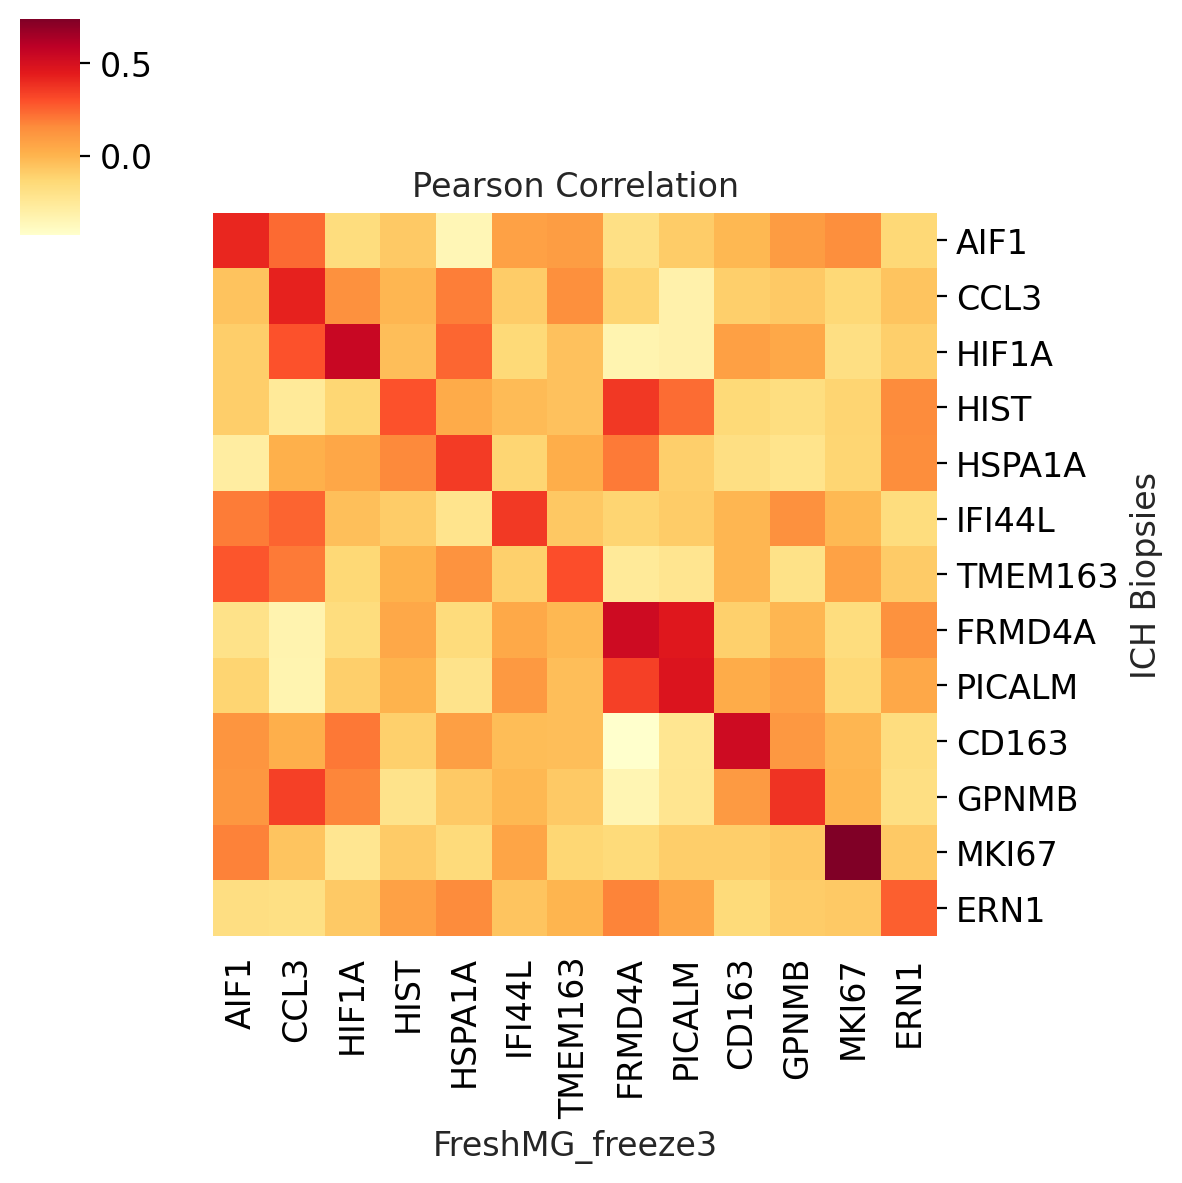

In [20]:
g = sns.clustermap(pge.pearson_corr(Fresh_scaled_sorted_reordered,
                                    Biopsies_scaled_sorted_reordered), 
                   annot=False, cmap="YlOrRd", figsize=(6, 6),
                   row_cluster=False, col_cluster=False)
ax = g.ax_heatmap
ax.set_xlabel('FreshMG_freeze3')
ax.set_ylabel('ICH Biopsies')
ax.set_title('Pearson Correlation')
fig = ax.get_figure()
fig.savefig(output_png1) 


In [15]:
fig.savefig('SupFigures/SFigure2A.pdf') 
